<a href="https://colab.research.google.com/github/m-ony/mineria-de-datos/blob/main/Liga_MX_jornada_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Liga MX jornada 17

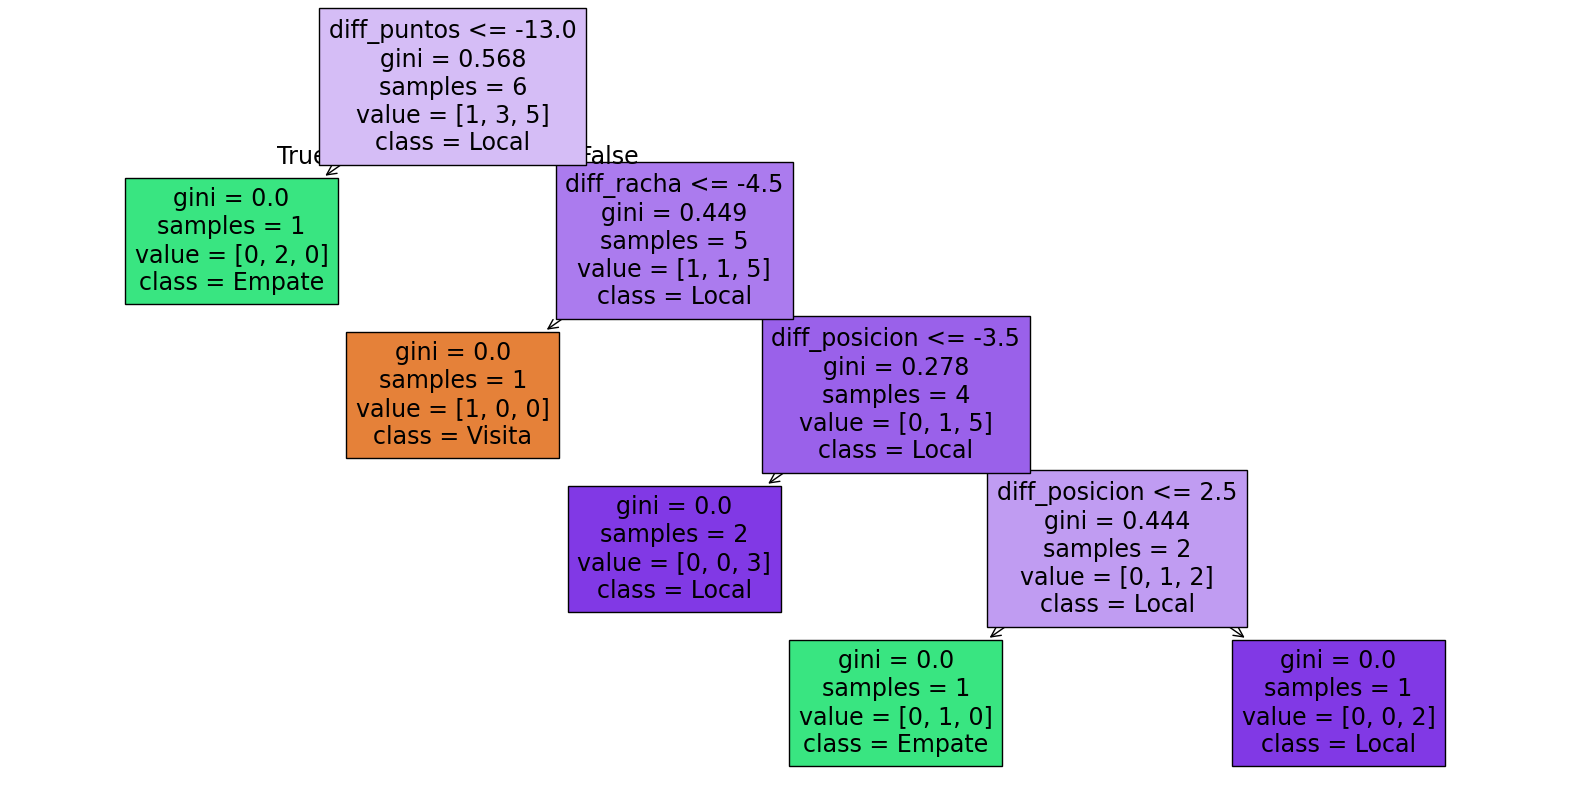

In [2]:
# Predicción de Resultados de Liga MX con Random Forest

#Libreta didáctica para Google Colab
## Objetivo

#Aplicar Machine Learning supervisado para predecir resultados de partidos de Liga MX usando Random Forest.

import pandas as pd
import numpy as np

## Cargar dataset
df = pd.read_csv('dataset_liga_mx_jornadas_16_base.csv')
df.head()

## Selección de features
features = ['diff_puntos','diff_racha','diff_posicion']
X = df[features]
y = df['Resultado']

## Entrenamiento del Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X, y)

## Importancia de variables
importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values(ascending=False)

## Visualización de un árbol
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0], feature_names=features, class_names=['Visita','Empate','Local'], filled=True)
plt.show()

In [6]:
tabla = pd.DataFrame([
    ['Puebla','Querétaro', -4, -4, 3],
    ['Pachuca','Pumas', -2, 1, 1],
    ['Tigres','Mazatlán', 7, -5, -7],
    ['Toluca','León', 5, 3, -3],
    ['Chivas','Tijuana', -4, 4, -9],
    ['América','Atlas', 2, -1, -1],
    ['FC Juárez','San Luis', -2, -6, 0],
    ['Santos','Monterrey', -9, -3, 7],
    ['Cruz Azul','Necaxa', 12, -1, -7]
], columns=['equipo_local','equipo_visita','diff_puntos','diff_racha','diff_posicion'])

In [7]:
predicciones = rf.predict(tabla[['diff_puntos','diff_racha','diff_posicion']])

tabla['pred'] = predicciones
tabla

,equipo_local,equipo_visita,diff_puntos,diff_racha,diff_posicion,pred
0,Puebla,Querétaro,-4,-4,3,2
1,Pachuca,Pumas,-2,1,1,1
2,Tigres,Mazatlán,7,-5,-7,2
3,Toluca,León,5,3,-3,1
4,Chivas,Tijuana,-4,4,-9,2
5,América,Atlas,2,-1,-1,1
6,FC Juárez,San Luis,-2,-6,0,0
7,Santos,Monterrey,-9,-3,7,2
8,Cruz Azul,Necaxa,12,-1,-7,2


In [8]:
predicciones_jornada16 = tabla[['equipo_local', 'equipo_visita']].copy()
for i in range(len(tabla)):
  if tabla['pred'][i]== 0:
    predicciones_jornada16.loc[i, 'Predicción'] = "Gana visitante"
  if tabla['pred'][i]== 1:
    predicciones_jornada16.loc[i, 'Predicción'] = "Empate"
  if tabla['pred'][i]== 2:
    predicciones_jornada16.loc[i, 'Predicción'] = "Gana Local"
predicciones_jornada16

,equipo_local,equipo_visita,Predicción
0,Puebla,Querétaro,Gana Local
1,Pachuca,Pumas,Empate
2,Tigres,Mazatlán,Gana Local
3,Toluca,León,Empate
4,Chivas,Tijuana,Gana Local
5,América,Atlas,Empate
6,FC Juárez,San Luis,Gana visitante
7,Santos,Monterrey,Gana Local
8,Cruz Azul,Necaxa,Gana Local
